## Data Analysis

- Review train data, explore data properties
- Review 3 sets of test data

### Train Data

In [1]:
# import library
import numpy as np
import pandas as pd
import os
import json
import ast
from datetime import datetime

from surprise import Reader, Dataset, SVD, SVDpp,KNNWithZScore
from scipy import sparse
from scipy.sparse import csr_matrix
from sklearn.utils.extmath import randomized_svd
from sklearn.metrics import mean_squared_error
from scipy import sparse


In [2]:
# import file
with open('train.json') as f:
    raw=[ast.literal_eval(l) for l in f.readlines()]
df = pd.DataFrame(raw)

In [3]:
df=df.sort_values(ascending=True,by=['unixReviewTime'])
df2 = df[['reviewerID','itemID', 'rating']]

In [4]:
# key features
df[['reviewTime','reviewerID','itemID', 'rating','categoryID','categories','reviewText']].head(1)

,reviewTime,reviewerID,itemID,rating,categoryID,categories,reviewText
31976,"03 29, 2003",U822358752,I140941298,5.0,0,"[[Clothing, Shoes & Jewelry, Women, Clothing, ...",This bra is the most comfortable bra I have ev...


In [5]:
# data size
print('Train data size: ', len(df))
print('Total unique items: ', len(df['itemID'].unique()))
print('Total unique users: ', len(df['reviewerID'].unique()))


Train data size:  200000
Total unique items:  19914
Total unique users:  39239


#### Sparsity

In [6]:
from scipy import sparse
from scipy.sparse import csr_matrix
df3=df2.copy()
df3['reviewerID'] = df2['reviewerID'].astype('category')
df3['itemID'] = df2['itemID'].astype('category')
df3['reviewerID'] = df3['reviewerID'].cat.codes
df3['itemID'] = df3['itemID'].cat.codes
sparse_matrix = sparse.csr_matrix((df3.rating.values, (df3.reviewerID.values,df3.itemID.values)))

us,mv = sparse_matrix.shape
elem = sparse_matrix.count_nonzero()
sparsity = np.round((1-(elem/(us*mv)))*100,5)

print("Sparsity of Train matrix : {}%".format(sparsity))

Sparsity of Train matrix : 99.97441%


#### Rating Distribution

Text(0.5, 0, 'Rating')

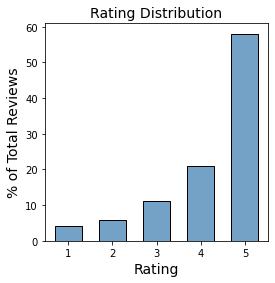

In [7]:
# rating distribution

%matplotlib inline

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(4,4))
sns.histplot(x=df.rating,stat='percent',color='steelblue', shrink=18)
#df['rating'].hist(bins=8)
plt.title('Rating Distribution', fontsize=14)
plt.ylabel('% of Total Reviews', fontsize=14)
plt.xlabel('Rating', fontsize=14)
#plt.xticks(rotation='vertical');

#### Category Distribution

Text(0.5, 0, 'Category ID')

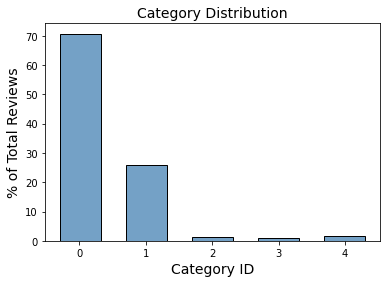

In [8]:
plt.figure(figsize=(6,4))
#sns.countplot(x=df.categoryID,color='steelblue')
sns.histplot(x=df.categoryID,stat='percent',color='steelblue', shrink=18)
plt.title('Category Distribution', fontsize=14)
plt.ylabel('% of Total Reviews', fontsize=14)
plt.xlabel('Category ID', fontsize=14)
#plt.xticks(rotation='vertical');

#### Review Year Disribution

/var/folders/wp/4_k9mkln78v7zyw4dbfbzvnh0000gn/T/ipykernel_33443/404181182.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3['date'] = pd.to_datetime(df3['unixReviewTime'].apply(datetime.utcfromtimestamp))
/var/folders/wp/4_k9mkln78v7zyw4dbfbzvnh0000gn/T/ipykernel_33443/404181182.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3['year'] = df3['date'].dt.year


Text(0.5, 0, 'Year')

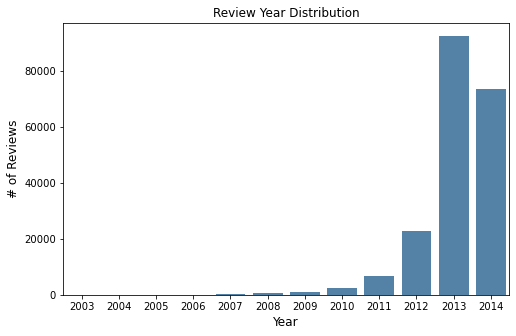

In [9]:
df3 = df[['reviewerID','itemID', 'rating','unixReviewTime']]
df3['date'] = pd.to_datetime(df3['unixReviewTime'].apply(datetime.utcfromtimestamp))
df3['year'] = df3['date'].dt.year
plt.figure(figsize=(8,5))
sns.countplot(x=df3.year,color='steelblue')
plt.title('Review Year Distribution', fontsize=12)
plt.ylabel('# of Reviews', fontsize=12)
plt.xlabel('Year', fontsize=12)

#### Popularity Distribution

In [10]:
items_freq = df['itemID'].value_counts()
plt_list = items_freq.value_counts().sort_index()

In [11]:
df.groupby('itemID')['rating'].mean().sort_values(ascending=False).head()
df.groupby('itemID')['rating'].count().sort_values(ascending=False).head()
ratings_mean_count = pd.DataFrame(df.groupby('itemID')['rating'].mean())
ratings_mean_count['rating_counts'] = pd.DataFrame(df.groupby('itemID')['rating'].count())
ratings_mean_count.head(1)

,rating,rating_counts
itemID,,
I000024906,4.090909,11


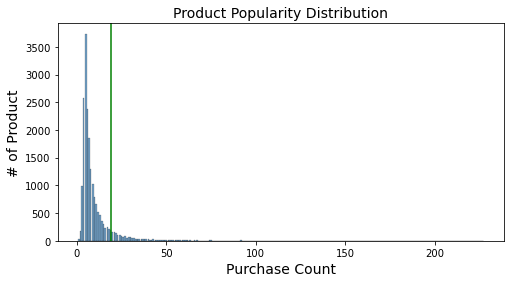

In [12]:
plt.figure(figsize=(8,4))
#plt.rcParams['patch.force_edgecolor'] = False
#ratings_mean_count['rating_counts'].hist(bins=50)
sns.histplot(x=ratings_mean_count.rating_counts,stat='count',color='steelblue', shrink=2)
plt.title('Product Popularity Distribution', fontsize=14)
plt.ylabel('# of Product', fontsize=14)
plt.xlabel('Purchase Count', fontsize=14)
plt.axvline(x=19,color='green')

#### Average Rating Distribution

Text(0.5, 0, 'Product Average Rating')

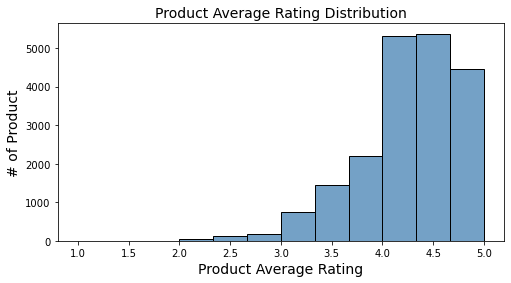

In [13]:
plt.figure(figsize=(8,4))
plt.rcParams['patch.force_edgecolor'] = False
#ratings_mean_count['rating'].hist(bins=50)
sns.histplot(x=ratings_mean_count.rating,stat='count',color='steelblue', bins=12)

plt.title('Product Average Rating Distribution', fontsize=14)
plt.ylabel('# of Product', fontsize=14)
plt.xlabel('Product Average Rating', fontsize=14)

<Figure size 576x360 with 0 Axes>

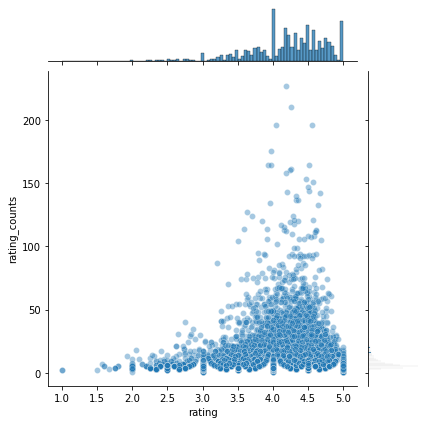

In [14]:
plt.figure(figsize=(8,5))
sns.jointplot(x='rating', y='rating_counts', data=ratings_mean_count, alpha=0.4)

### Rating Test Data

In [15]:
raw_test=[]
with open('pairs_Rating.txt') as f:
    raw_test=[l.strip().split('-') for l in f.readlines() if (l.startswith("reviewerID")==0)]
df_test = pd.DataFrame(raw_test)

In [16]:
print('Train test data size: ', len(df_test))
print('Total unique items in test data: ', len(df_test[1].unique()))
print('Total unique users in test data: ', len(df_test[0].unique()))

Train test data size:  14000
Total unique items in test data:  8691
Total unique users in test data:  11637


In [17]:
exist_user=df['reviewerID'].to_list()
exist_item=df['itemID'].to_list()
new_user_count=0
new_item_count=0

In [18]:
exist_user=df['reviewerID'].to_list()
exist_item=df['itemID'].to_list()
test_user=df_test[0].to_list()
test_item=df_test[1].to_list()

In [19]:
# number of new items in test data
for i in df_test[1]:
    if i not in exist_item:
        new_item_count+=1
print('Total # of new items: {}'.format(new_item_count))

Total # of new items: 1


In [20]:
# number of new users in test data
for i in df_test[0]:
    if i not in exist_user:
        new_user_count+=1
print('Total # of new users: {}'.format(new_user_count))


Total # of new users: 55


### Purchase Test Data 

In [21]:
raw_test=[]
with open('pairs_Purchase.txt') as f:
    raw_test=[l.strip().split('-') for l in f.readlines() if (l.startswith("reviewerID")==0)]
df_test = pd.DataFrame(raw_test)

In [22]:
print('Train test data size: ', len(df_test))
print('Total unique items in test data: ', len(df_test[1].unique()))
print('Total unique users in test data: ', len(df_test[0].unique()))

Train test data size:  28000
Total unique items in test data:  14447
Total unique users in test data:  19871


In [23]:
exist_user=df['reviewerID'].to_list()
exist_item=df['itemID'].to_list()
new_user_count=0
new_item_count=0

In [24]:
# number of new items in test data
for i in df_test[1]:
    if i not in exist_item:
        new_item_count+=1
print('Total # of new items: {}'.format(new_item_count))

Total # of new items: 3


In [25]:
# number of new users in test data
for i in df_test[0]:
    if i not in exist_user:
        new_user_count+=1
print('Total # of new users: {}'.format(new_user_count))

Total # of new users: 101


### Category Test Data 

In [26]:
len(df['reviewHash'].unique())

200000

In [27]:
raw_test=[]
with open('pairs_Category.txt') as f:
    raw_test=[l.strip().split('-') for l in f.readlines() if (l.startswith("reviewerID")==0)]
df_test = pd.DataFrame(raw_test)

print('Train test data size: ', len(df_test))
print('Total unique reviews in test data: ', len(df_test[1].unique()))
print('Total unique users in test data: ', len(df_test[0].unique()))

exist_user=df['reviewerID'].to_list()
exist_item=df['reviewHash'].to_list()
new_user_count=0
new_item_count=0

Train test data size:  14000
Total unique reviews in test data:  14000
Total unique users in test data:  11698


In [28]:
# number of new users in test data
for i in df_test[0]:
    if i not in exist_user:
        new_user_count+=1
print('Total # of new users: {}'.format(new_user_count))

Total # of new users: 48
